In [21]:
!git clone https://github.com/amine-banani/atelier-ia-images.git
%cd atelier-ia-images

Cloning into 'atelier-ia-images'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 4.13 MiB | 15.73 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/kaggle/working/atelier-ia-images/atelier-ia-images


In [22]:
IMAGE_PATH = "maria-sime-349-eXDixFE-unsplash.jpg"

# Comment une IA voit-elle une image ?

Prenez quelques secondes.

**Qu’est-ce que vous voyez ?**

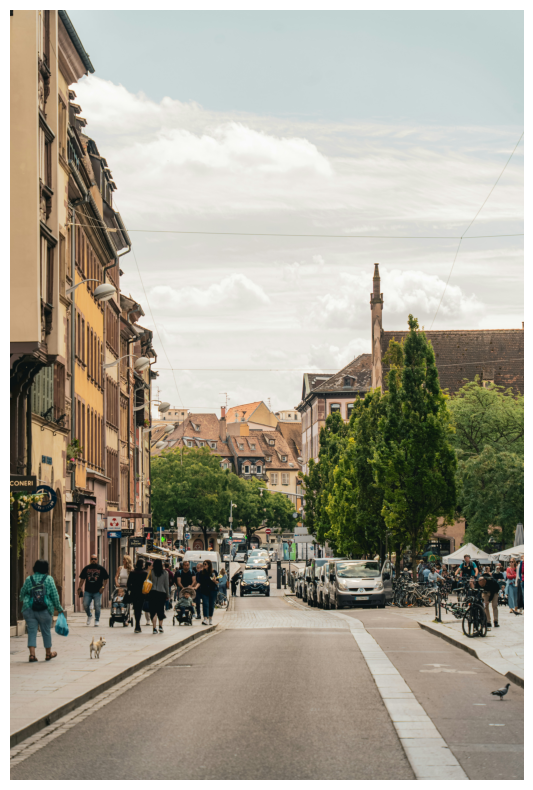

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(16, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

## Et au-delà des objets ?

**Qu’est-ce que vous comprenez de la scène ?**

---

Nous venons de reconnaître des objets, des relations et un contexte.

Mais l’ordinateur, lui, ne reçoit rien de tout cela directement.

**Alors, qu’est-ce qu’il reçoit réellement ?**

In [24]:
import numpy as np

arr = np.array(image)

print("Taille de l'image :", arr.shape)
print("Type des valeurs :", arr.dtype)
print("Exemple d'un pixel RGB :", arr[200, 300])

Taille de l'image : (7008, 4672, 3)
Type des valeurs : uint8
Exemple d'un pixel RGB : [172 141 113]


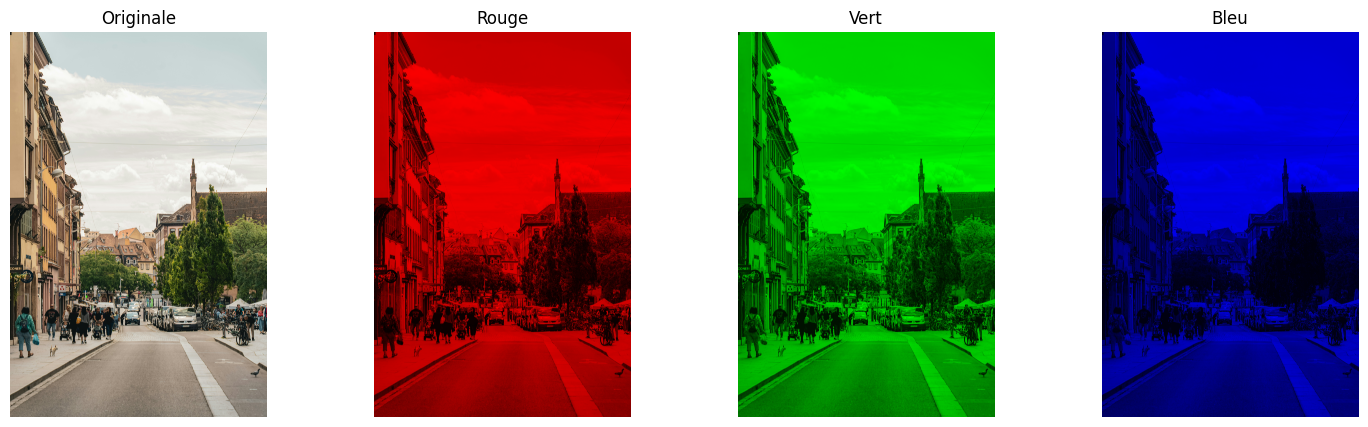

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(arr)
axes[0].set_title("Originale")

colors = [
    (0, "Rouge"),
    (1, "Vert"),
    (2, "Bleu")
]

for j, (i, name) in enumerate(colors, start=1):
    channel_img = np.zeros_like(arr)
    channel_img[:, :, i] = arr[:, :, i]

    axes[j].imshow(channel_img)
    axes[j].set_title(name)

for ax in axes:
    ax.axis("off")

plt.show()

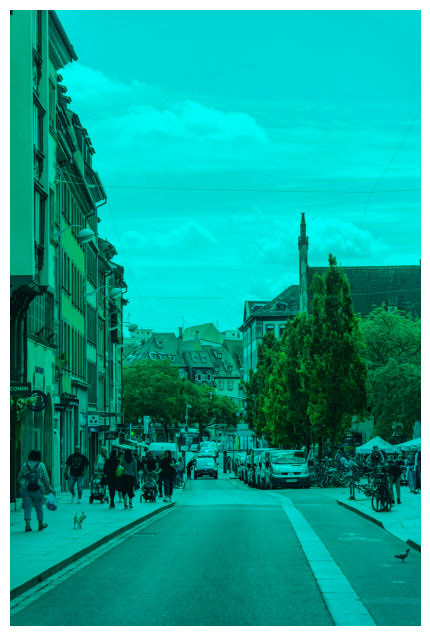

In [26]:
def remove_channel(image_array, channel):
    out = image_array.copy()
    idx = {"red": 0, "green": 1, "blue": 2}[channel]
    out[:, :, idx] = 0
    return out

modified = remove_channel(arr, "red")

plt.figure(figsize=(14, 8))
plt.imshow(modified)
plt.axis("off")
plt.show()

# 2. Classification

Jusqu’ici, nous avons regardé l’image comme une donnée numérique.

Maintenant, donnons-la à un modèle déjà entraîné pour reconnaître des catégories d’images.

**Question : si on oblige le modèle à résumer toute cette scène avec une seule étiquette, que va-t-il répondre ?**

In [27]:
import torch
from torchvision.models import resnet50, ResNet50_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights).to(device)
model.eval()

preprocess = weights.transforms()
labels = weights.meta["categories"]

In [28]:
import matplotlib.pyplot as plt

def classify(image, topk=5):
    x = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]

    values, indices = probs.topk(topk)

    results = [
        (labels[idx], float(prob))
        for prob, idx in zip(values, indices)
    ]

    names = [r[0] for r in results][::-1]
    scores = [r[1] * 100 for r in results][::-1]

    plt.figure(figsize=(8, 4))
    plt.barh(names, scores)
    plt.xlabel("Confiance (%)")
    plt.title("Top 5 prédictions")
    plt.show()

    return results

## Prédiction du modèle

Le modèle utilisé ici a été entraîné sur ImageNet, avec 1000 catégories possibles.

Il ne cherche donc pas à décrire toute la scène : il cherche la catégorie qui ressemble le plus à ce qu’il a appris.

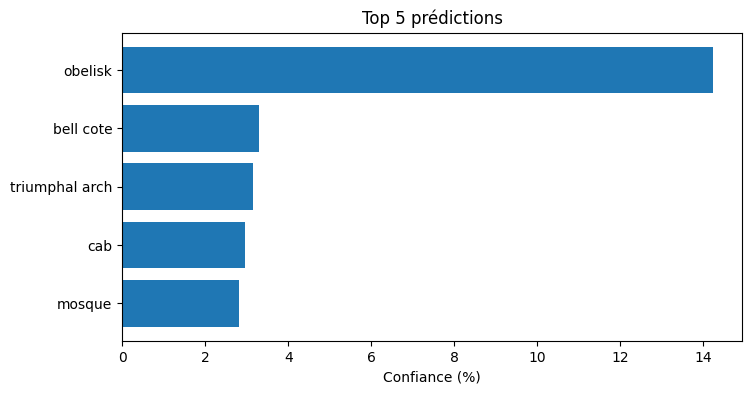

[('obelisk', 0.14219126105308533),
 ('bell cote', 0.033072758466005325),
 ('triumphal arch', 0.031473834067583084),
 ('cab', 0.0297094713896513),
 ('mosque', 0.028126290068030357)]

In [29]:
results = classify(image)
results

## À retenir

Le modèle ne répond pas à :

**« Qu’est-ce qu’il y a dans cette scène ? »**

Il répond plutôt à :

**« Parmi les catégories que je connais, laquelle correspond le mieux à cette image ? »**

Même image, mais une tâche très précise.

### Ce qu’on observe

Le modèle ne reconnaît pas réellement "la scène" dans son ensemble.

Ses principales prédictions concernent surtout :
- l’architecture ;
- la tour au centre ;
- certains éléments urbains comme les voitures.

La confiance maximale reste faible, autour de 14 %.

Cela indique que le modèle hésite : cette image complexe ne correspond pas vraiment à une seule des catégories sur lesquelles il a été entraîné.

**Point clé :** on demande ici à un modèle de classification de résumer toute une scène avec une seule étiquette. La tâche est donc volontairement limitée.

### Question

Le modèle a donné une réponse.

Mais **sur quelles parties de l’image s’est-il appuyé pour décider ?**

Avant de regarder ça, voyons rapidement comment l’image est transformée à l’intérieur du réseau.

# 3. Que se passe-t-il à l’intérieur du réseau ?

L’image n’est pas directement transformée en une étiquette.

À chaque étape du réseau, elle est convertie en de nouvelles représentations.

Nous allons regarder quelques activations internes, sans chercher à interpréter chaque neurone individuellement.

In [30]:
# Couches de ResNet50 que l'on veut observer
selected_layers = {
    "conv1": model.conv1,
    "layer2": model.layer2,
    "layer4": model.layer4,
}

activations = {}

def save_activation(name):
    def hook(module, input, output):
        activations[name] = output.detach().cpu()
    return hook

hooks = []

for name, layer in selected_layers.items():
    hooks.append(layer.register_forward_hook(save_activation(name)))

# Passage de l'image dans le réseau
x = preprocess(image).unsqueeze(0).to(device)

with torch.no_grad():
    _ = model(x)

# Nettoyage des hooks
for hook in hooks:
    hook.remove()

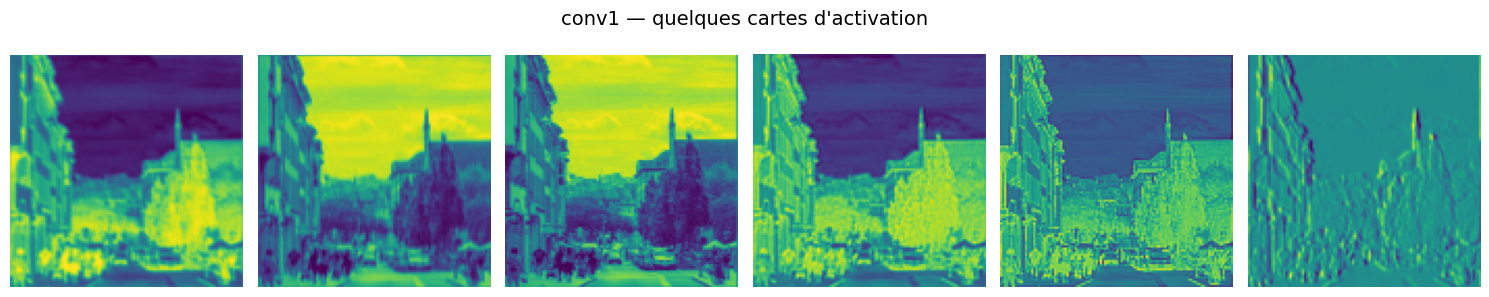

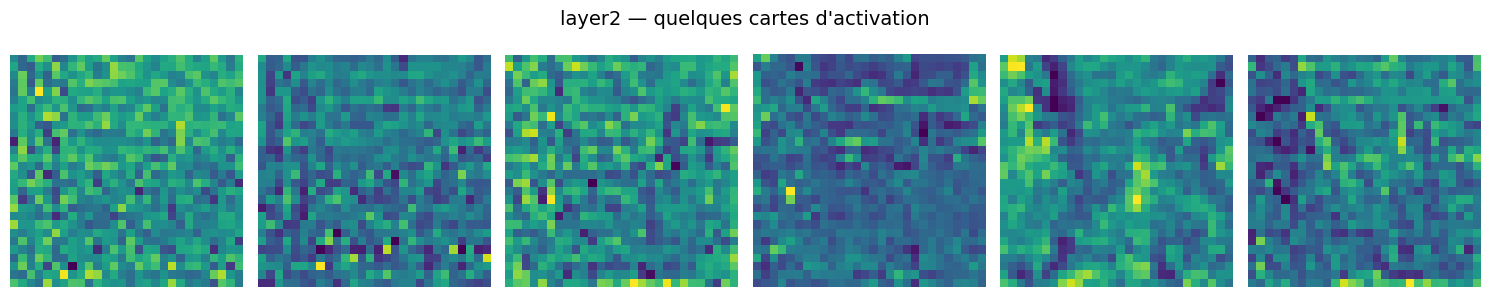

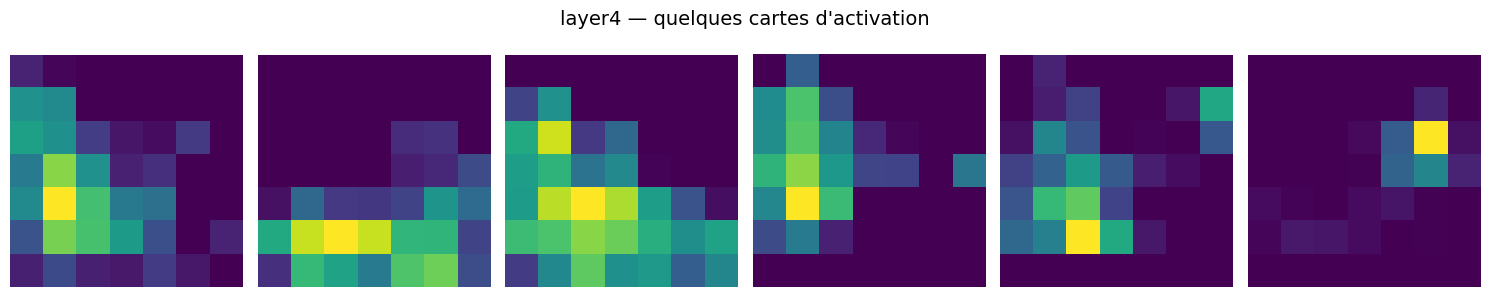

In [31]:
def show_feature_maps(activations, n_maps=6):
    for layer_name, activation in activations.items():
        feature_maps = activation[0]

        # On choisit les cartes les plus actives en moyenne
        scores = feature_maps.abs().mean(dim=(1, 2))
        indices = torch.topk(scores, k=min(n_maps, len(scores))).indices

        fig, axes = plt.subplots(
            1,
            len(indices),
            figsize=(15, 3)
        )

        fig.suptitle(
            f"{layer_name} — quelques cartes d'activation",
            fontsize=14
        )

        if len(indices) == 1:
            axes = [axes]

        for ax, idx in zip(axes, indices):
            ax.imshow(feature_maps[idx], cmap="viridis")
            ax.axis("off")

        plt.tight_layout()
        plt.show()

show_feature_maps(activations)

### Ce qu’on observe

Les représentations changent fortement au fur et à mesure que l’on avance dans le réseau.

- Dans les premières couches, les activations restent très liées aux structures locales de l’image : contours, contrastes, textures.
- Plus profondément, elles deviennent plus abstraites et plus directement utiles pour la tâche de classification.

Une carte d’activation isolée ne correspond pas nécessairement à un objet précis.

### Question

Le réseau transforme donc progressivement l’image.

Mais au moment de prédire une classe, **quelles zones de l’image ont réellement influencé sa décision ?**

# 4. Quelles zones ont influencé la prédiction ?

Le modèle a prédit principalement **"obelisk"**.

Mais quelles régions de l’image ont contribué à cette décision ?

Avant d’exécuter la visualisation :

**D’après vous, où le modèle a-t-il regardé ?**

In [32]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# On utilise la dernière couche convolutionnelle de ResNet50
target_layer = model.layer4[-1]

activations_gradcam = {}
gradients_gradcam = {}

def forward_hook(module, input, output):
    activations_gradcam["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients_gradcam["value"] = grad_output[0]

hook_forward = target_layer.register_forward_hook(forward_hook)
hook_backward = target_layer.register_full_backward_hook(backward_hook)


def gradcam(image, class_idx=None):
    model.zero_grad()

    x = preprocess(image).unsqueeze(0).to(device)

    logits = model(x)

    if class_idx is None:
        class_idx = logits.argmax(dim=1).item()

    score = logits[0, class_idx]
    score.backward()

    activations = activations_gradcam["value"][0]
    gradients = gradients_gradcam["value"][0]

    weights = gradients.mean(dim=(1, 2))

    cam = torch.sum(
        weights[:, None, None] * activations,
        dim=0
    )

    cam = F.relu(cam)

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    cam = cam.detach().cpu().numpy()

    return cam, class_idx

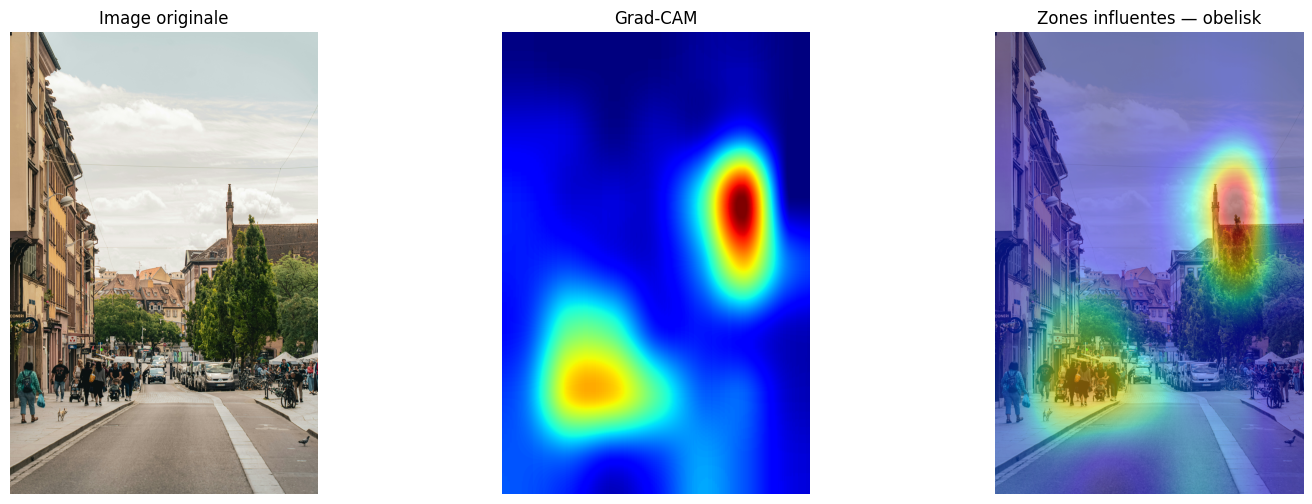

In [33]:
cam, class_idx = gradcam(image)

predicted_class = labels[class_idx]

cam_resized = np.array(
    Image.fromarray(
        np.uint8(cam * 255)
    ).resize(image.size)
) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Image originale")

axes[1].imshow(cam_resized, cmap="jet")
axes[1].set_title("Grad-CAM")

axes[2].imshow(image)
axes[2].imshow(cam_resized, cmap="jet", alpha=0.45)
axes[2].set_title(f"Zones influentes — {predicted_class}")

for ax in axes:
    ax.axis("off")

plt.show()

### Ce qu’on observe

Grad-CAM ne montre pas exactement "ce que le modèle voit".

Il indique plutôt **quelles régions de l’image ont le plus contribué à une prédiction donnée**.

Si la prédiction est "obelisk", on peut vérifier si le modèle s’appuie réellement sur la tour centrale ou sur d’autres éléments du contexte urbain.

**Point clé :** une prédiction peut dépendre d’indices visuels qui ne correspondent pas forcément à notre propre manière d’interpréter la scène.

## Et si on modifiait l’image ?

Maintenant que nous savons où le modèle semble s’appuyer, essayons de voir à quel point sa prédiction est robuste.

**Que se passe-t-il si on floute, tourne, recadre ou masque certaines parties de l’image ?**

# 5. Testons la robustesse du modèle

Jusqu’ici, nous avons utilisé l’image telle quelle.

Maintenant, modifions-la légèrement et observons si la prédiction reste stable.

**Question : quelle transformation pensez-vous qui perturbera le plus le modèle ?**

In [34]:
from PIL import ImageEnhance, ImageFilter, ImageOps
import numpy as np

experiment_results = []

def run_classification(image):
    x = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]

    value, index = probs.max(dim=0)

    return labels[index.item()], value.item()


def experiment(image, effect, strength=1):
    if effect == "blur":
        modified = image.filter(ImageFilter.GaussianBlur(radius=strength))

    elif effect == "brightness":
        modified = ImageEnhance.Brightness(image).enhance(strength)

    elif effect == "rotation":
        modified = image.rotate(strength, expand=False, fillcolor=(255, 255, 255))

    elif effect == "grayscale":
        modified = ImageOps.grayscale(image).convert("RGB")

    elif effect == "noise":
        arr = np.array(image).astype(np.float32)
        noise = np.random.normal(0, strength, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        modified = Image.fromarray(arr)

    else:
        raise ValueError("Transformation inconnue")

    pred, confidence = run_classification(modified)

    experiment_results.append({
        "Transformation": effect,
        "Classe": pred,
        "Confiance (%)": confidence * 100
    })

    plt.figure(figsize=(8, 6))
    plt.imshow(modified)
    plt.title(f"{effect} → {pred} ({confidence*100:.1f} %)")
    plt.axis("off")
    plt.show()

    return modified

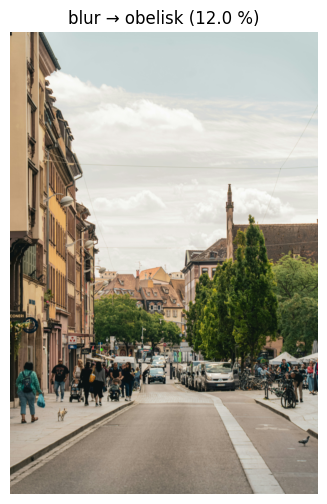

In [35]:
_ = experiment(image, "blur", 4)

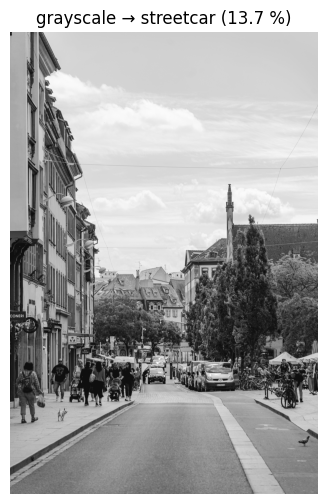

In [36]:
_ = experiment(image, "grayscale")

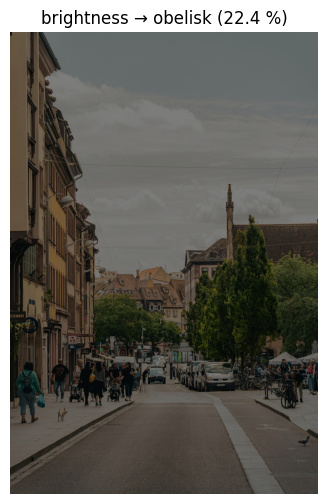

In [37]:
_ = experiment(image, "brightness", 0.5)

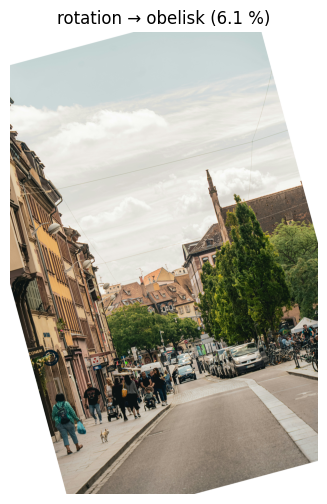

In [38]:
_ = experiment(image, "rotation", 15)

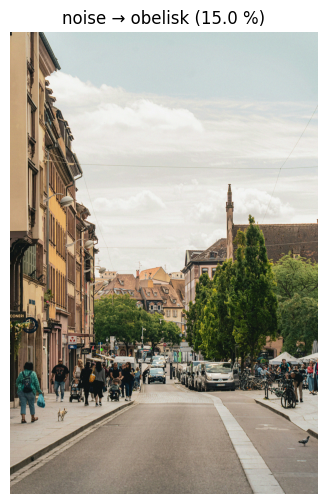

In [39]:
_ = experiment(image, "noise", 20)

In [40]:
import pandas as pd

pd.DataFrame(experiment_results)

,Transformation,Classe,Confiance (%)
0,blur,obelisk,11.975004
1,grayscale,streetcar,13.738820
2,brightness,obelisk,22.369371
3,rotation,obelisk,6.114375
4,noise,obelisk,14.980073


### Ce qu’on observe

Certaines transformations changent peu la prédiction, d’autres beaucoup plus.

Le modèle peut donc être :
- relativement robuste à certaines variations ;
- sensible à d’autres modifications pourtant faciles à interpréter pour un humain.

La question importante n’est pas seulement **“est-ce que le modèle a raison ?”**, mais aussi :

**“dans quelles conditions sa réponse reste-t-elle stable ?”**

## 5.1 Cacher une partie de l’image

Jusqu’ici, nous avons modifié toute l’image.

Mais que se passe-t-il si on cache uniquement une zone précise ?

**Question : quelle zone faudrait-il masquer pour faire disparaître la prédiction "obelisk" ?**

In [41]:
from PIL import ImageDraw

def occlude(image, box, label="occlusion"):
    modified = image.copy()

    draw = ImageDraw.Draw(modified)
    draw.rectangle(box, fill=(128, 128, 128))

    pred, confidence = run_classification(modified)

    experiment_results.append({
        "Transformation": label,
        "Classe": pred,
        "Confiance (%)": confidence * 100
    })

    plt.figure(figsize=(8, 6))
    plt.imshow(modified)
    plt.title(f"{label} → {pred} ({confidence*100:.1f} %)")
    plt.axis("off")
    plt.show()

    return modified

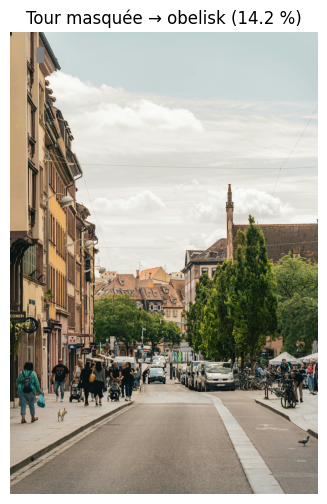

In [42]:
_ = occlude(
    image,
    box=(400, 230, 520, 470),
    label="Tour masquée"
)

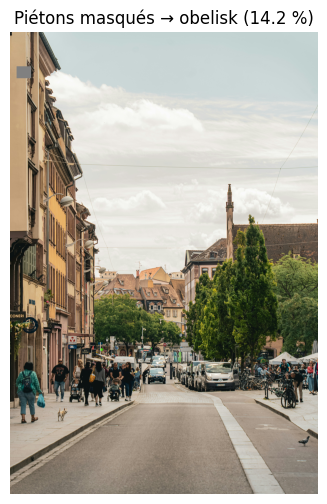

In [43]:
_ = occlude(
    image,
    box=(100, 520, 320, 700),
    label="Piétons masqués"
)

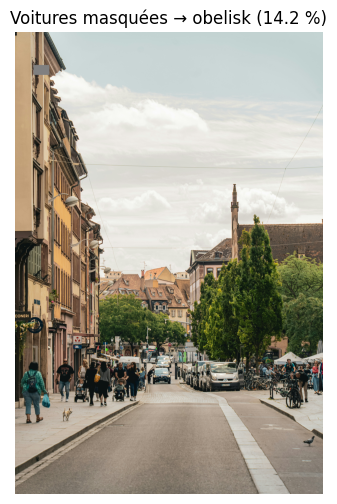

In [44]:
_ = occlude(
    image,
    box=(280, 500, 520, 650),
    label="Voitures masquées"
)

In [45]:
pd.DataFrame(experiment_results)

,Transformation,Classe,Confiance (%)
0,blur,obelisk,11.975004
1,grayscale,streetcar,13.738820
2,brightness,obelisk,22.369371
3,rotation,obelisk,6.114375
4,noise,obelisk,14.980073
5,Tour masquée,obelisk,14.219126
6,Piétons masqués,obelisk,14.219126
7,Voitures masquées,obelisk,14.219126


### Ce qu’on observe

Masquer certaines zones modifie beaucoup plus la prédiction que d’autres.

Si masquer la tour fait fortement chuter la confiance pour "obelisk", cela confirme ce que suggérait Grad-CAM : cette région joue un rôle important dans la décision.

On peut donc tester directement une hypothèse sur ce que le modèle utilise pour prédire.

# 6. Changeons complètement de tâche

Jusqu’ici, le modèle devait résumer toute l’image avec une seule classe.

Mais cette scène contient de nombreux objets.

**Et si on demandait plutôt au modèle de trouver chaque objet séparément ?**